# Online Expert Aggregation

## Framework 

In this notebook, we work in an **online expert aggregation** setting to forecast **daily bakery sales** \(y_t\), where \(y_t\) is the **number of items sold** for each of the **12 top products**. 

For each product, we define a small set of base forecasters (experts) that each produce a prediction y_hat_t at every time step. Our goal is to combine these experts into a single aggregated prediction y_hat_t using two algorithms from the course: **Exponentially Weighted Average (EWA)** and **Exponential Gradient (EG)**. 

Our choosen experts are :
- **Sarimax**
- **Holt**
- **Moving Average**


Beyond predictive performance, our main deliverable is interpretability: for each of the 12 products, we will track and visualize the **time evolution of the experts’ weights** w_(k,t). Concretely, the expected outputs are **12 weight trajectories plots** (one per product), showing how the aggregation dynamically shifts trust across experts over time.

## Import and EWA + EG functions building

In [12]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

### EWA implementation

Here we have **ewa_weight_uptade** and **ewa_forecasting**

**ewa_weight_uptade** is means to be use into the main function **ewa_forecasting**

**ewa_forecasting** does the algorithm for one product at a time, i.e. it needs only one of our timeseries and its previous previsions builded by "experts"

In [13]:
# EWA Weight Update
def ewa_weight_update(weights, sum_losses, eta):
    """
    Update expert weights using Exponentially Weighted Average (EWA) method.

    Parameters:
    weights (np.array): Current weights of the experts. Dim= K (number of experts).
    sum_losses (np.array): Sum of losses incurred by each expert up to time t. Dim = K (number of experts).
    eta (float): Learning rate.

    Returns:
    np.array: Updated weights of the experts. Dim= K (number of experts).
    """
    updated_weights = weights * np.exp(-eta * sum_losses)
    updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
    return updated_weights

In [14]:
# EWA Implementation
def ewa_forecasting(expert_forecasts, true_values, eta, loss_fn):
    """
    Perform forecasting using Exponentially Weighted Average (EWA) of expert predictions. Wish to keep track of the cumulative loss of each expert to update weights accordingly.

    Parameters:
    expert_forecasts (np.array): Forecasts from K experts over T time steps. Dim = T x K.
    true_values (np.array): True values over T time steps. Dim = T.
    eta (float): Learning rate.
    loss_fn (function): Loss function to evaluate expert performance.

    Returns:
    ewa_forecasts(np.array): EWA aggregated forecasts over T time steps. Dim = T.
    weights_history (np.array): History of expert weights over T time steps. Dim = T x K.
    """
    T, K = expert_forecasts.shape
    weights = np.ones(K) / K  # Initialize weights uniformly
    ewa_forecasts = np.zeros(T)
    sum_losses = np.zeros(K)  # Initialize sum of losses for each expert up to time t
    weights_history = np.zeros((T, K))  # To store weights at each time step

    for t in range(T):
        # Compute EWA forecast
        ewa_forecasts[t] = np.dot(weights, expert_forecasts[t])

        # Compute losses for each expert
        losses = loss_fn(expert_forecasts[t], true_values[t])
        sum_losses += losses

        # Update weights
        weights = ewa_weight_update(weights, sum_losses, eta)
        weights_history[t] = weights

    return ewa_forecasts, weights_history

### EWA gradient trick - Exponentiel Gradient (L2 loss) implementation

In [15]:
def EG_weight_update(weights, grad_t, eta):
    """
    Update expert weights using Exponentiated Gradient (EG) method with implicit L2 loss.

    Parameters:
    weights (np.array): Current weights of the experts. Dim= K (number of experts).
    gradient_t (np.array): Gradient of the loss with respect to expert weights at time t. Dim = K (number of experts).
    eta (float): Learning rate.
    """
    updated_weights = weights * np.exp(-eta * grad_t)
    s = updated_weights.sum()
    if s == 0 or not np.isfinite(s):
        # safety fallback (on a peut etre eu ce pb avec EWA)
        return np.ones_like(weights) / len(weights)
    updated_weights /= s

    return updated_weights

In [16]:
def EG_forecasting (expert_forecasts, true_values, eta):
    """
    Perform forecasting using Exponentiated Gradient (EG) of expert predictions with implicit L2 loss. Wish to keep track of the cumulative loss of each expert to update weights accordingly.

    Parameters:
    expert_forecasts (np.array): Forecasts from K experts over T time steps. Dim = T x K.
    true_values (np.array): True values over T time steps. Dim = T.
    eta (float): Learning rate.
    
    Returns:
    eg_forecasts(np.array): EG aggregated forecasts over T time steps. Dim = T.
    weights_history (np.array): History of expert weights over T time steps. Dim = T x K.
    """
    T, K = expert_forecasts.shape
    weights = np.ones(K) / K  # Initialize weights uniformly
    eg_forecasts = np.zeros(T)
    weights_history = np.zeros((T, K))  # To store weights at each time step

    for t in range(T):
        # store weights used at time t (w_t)
        weights_history[t] = weights

        # aggregated prediction ŷ_t = <w_t, f_t>
        f_t = expert_forecasts[t]              # shape (K,)
        y_hat_t = np.dot(weights, f_t)
        eg_forecasts[t] = y_hat_t

        # gradient per expert: g_{k,t} = 2(ŷ_t - y_t) f_{k,t}
        grad_t = 2.0 * (y_hat_t - true_values[t]) * f_t  # shape (K,)

        # EG update: w_{t+1,k} ∝ w_{t,k} * exp(-eta * g_{k,t})
        weights = EG_weight_update(weights, grad_t, eta)

    return eg_forecasts, weights_history

## Hyperparameters (loss function, eta, and experts forcasts)

### Loss functions

In [17]:
def squared_loss(y_true, y_pred):
    return (y_true - y_pred) ** 2

def rmse_fn(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def abs_loss(y_true, y_pred):
    return np.abs(y_true - y_pred)

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

### Eta lerning rate

In [18]:
choosen_eta = 0.00001

## Expert forecasts and true values generation

### load data

In [19]:
forecasts_df = pd.read_csv("data_tmp/predictions_experts_avec_futur.csv", index_col='Date', parse_dates=True)
forecasts_df = forecasts_df[['product', 'real_sale', 'expert_sarimax', 'expert_holt']]
expert_label = ['expert_sarimax', 'expert_holt', 'expert_naive', 'expert_ma']
etas_to_test = [0.0001, 0.001, 0.01, 0.1, 0.5]

# Our 12 y_true value
qty_ts = pd.read_csv("data_tmp/qty_ts.csv", index_col='date', parse_dates=True)
liste_products = qty_ts.columns.to_list()
#print(qty_ts)
print(forecasts_df)
forecasts_df.shape


                         product  real_sale  expert_sarimax  expert_holt
Date                                                                    
2021-01-02              BAGUETTE       46.0        0.000000    35.565728
2021-01-03              BAGUETTE       35.0       45.995025    46.506213
2021-01-04              BAGUETTE       30.0       38.968685    27.718052
2021-01-05              BAGUETTE       29.0       35.128788    28.219830
2021-01-06              BAGUETTE        0.0       33.513881     4.393184
...                          ...        ...             ...          ...
2022-10-03  TRADITIONAL BAGUETTE        NaN      143.766709   176.946580
2022-10-04  TRADITIONAL BAGUETTE        NaN      121.457658   146.895713
2022-10-05  TRADITIONAL BAGUETTE        NaN      118.476390   135.039020
2022-10-06  TRADITIONAL BAGUETTE        NaN      118.411337   136.982508
2022-10-07  TRADITIONAL BAGUETTE        NaN      120.963957   143.157309

[7728 rows x 4 columns]


(7728, 4)

## Inference on our 12 timeseries

In [20]:
# Create folder to export figures
FIG_DIR = "reports/Online_Expert_Aggregation_figures"
os.makedirs(FIG_DIR, exist_ok=True)

### Running and ploting EWA

Product              | Best Eta   | Test RMSE 
---------------------------------------------
BAGUETTE             | 0.0001     | 22.3176   


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


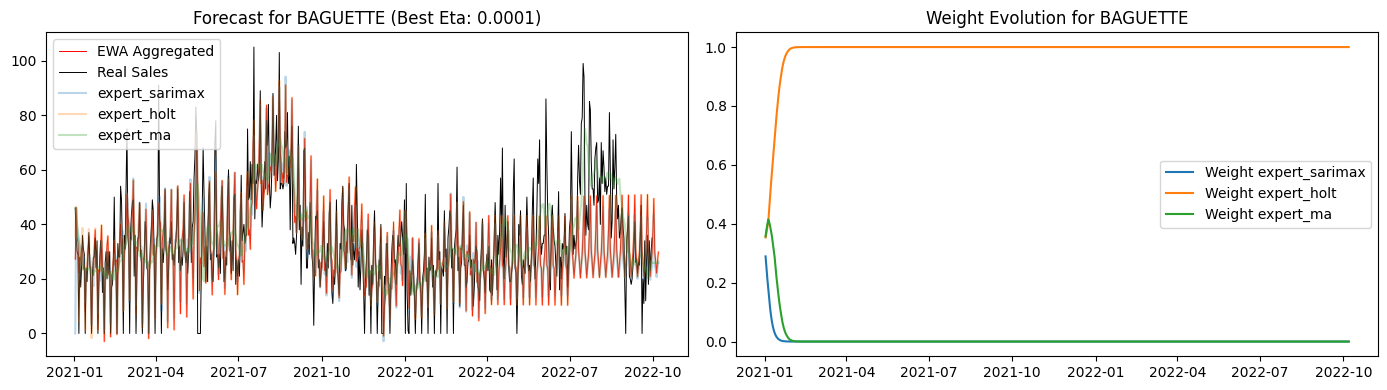

BANETTE              | 0.0001     | 29.6314   

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


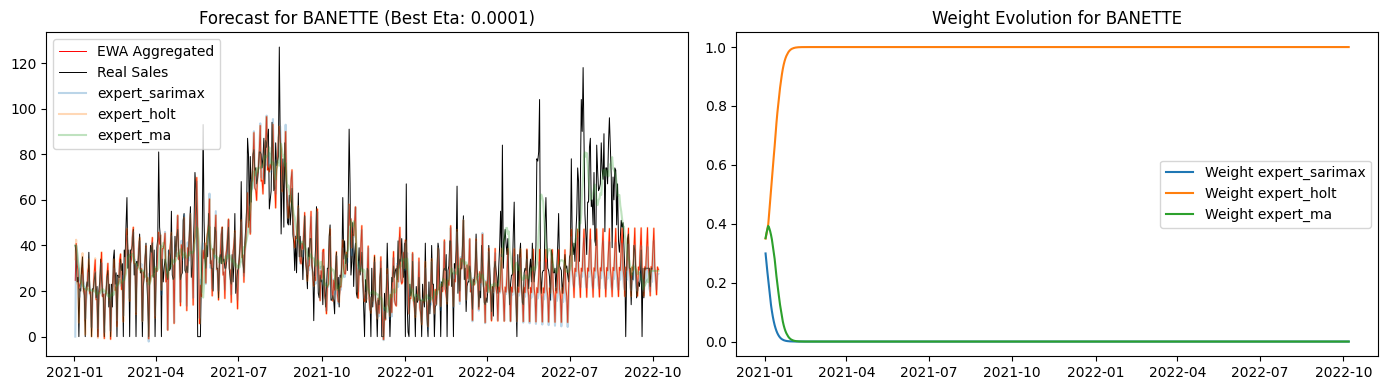

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


BOULE 400G           | 0.1        | nan       


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


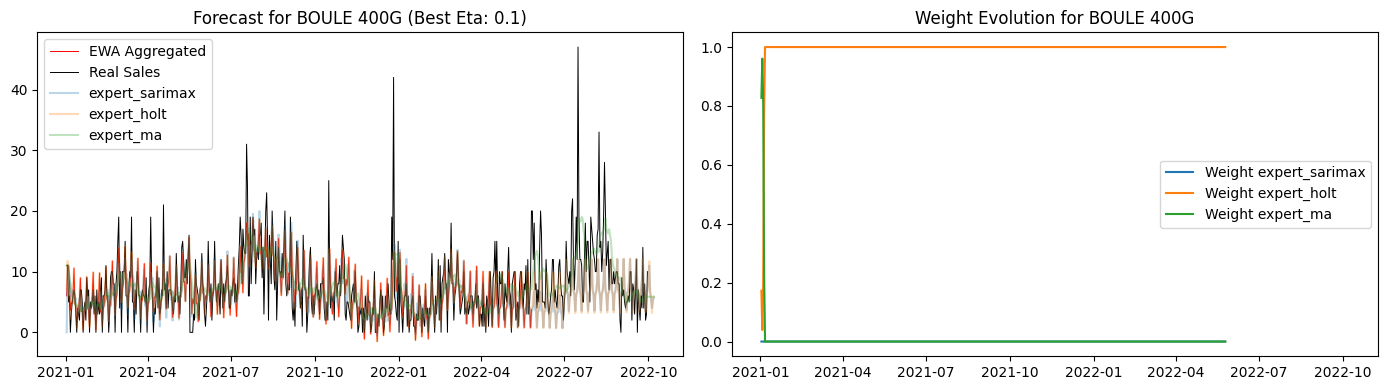

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


CAMPAGNE             | 0.001      | 6.2408    


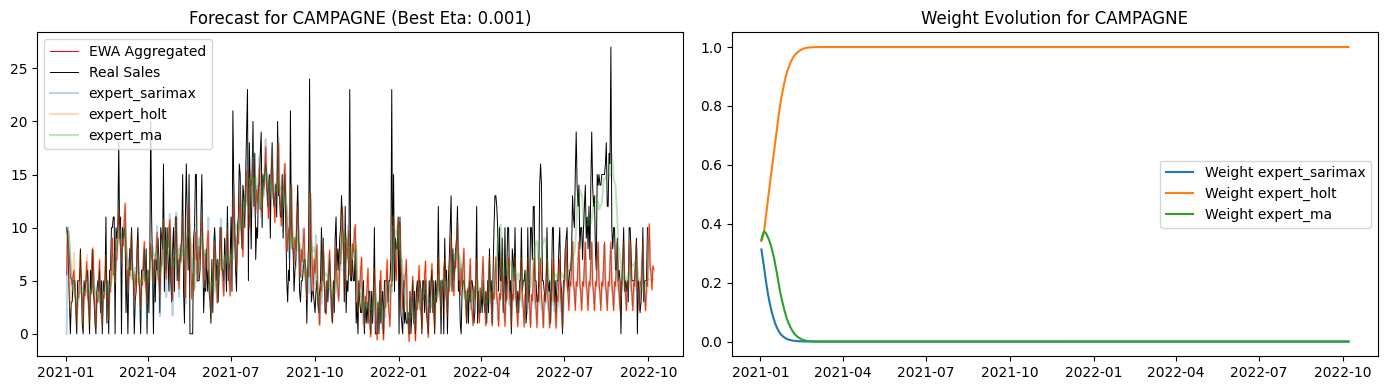

CEREAL BAGUETTE      | 0.0001     | 9.6447    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


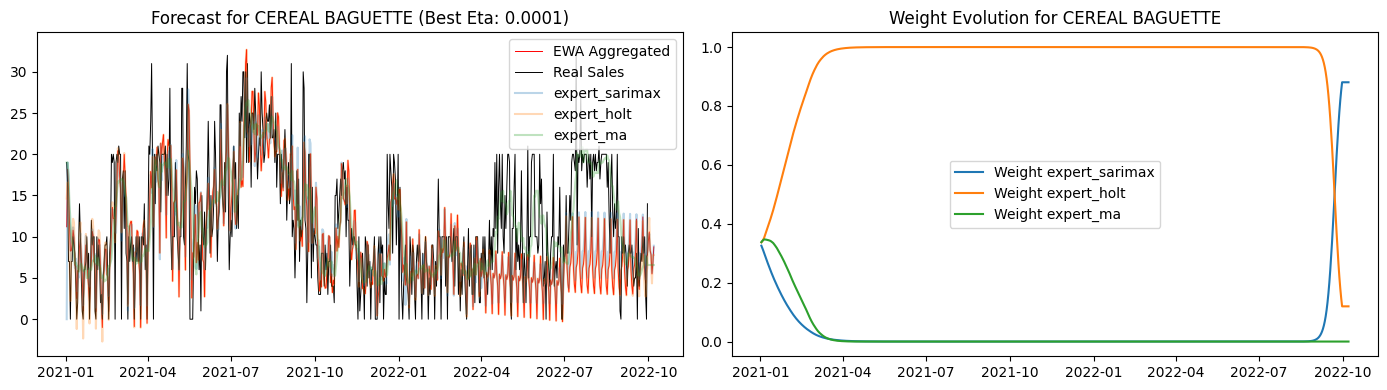

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


COOKIE               | 0.0001     | 7.3602    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


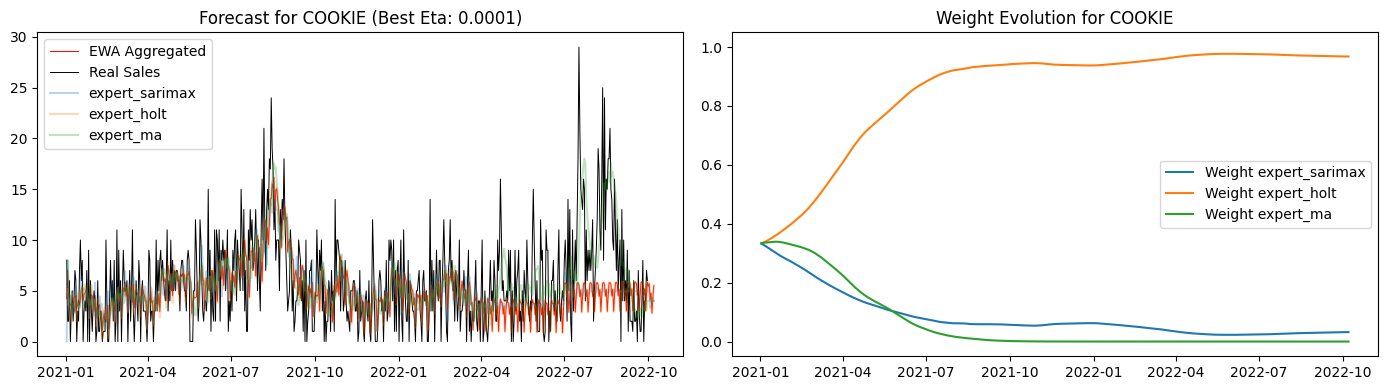

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


CROISSANT            | 0.0001     | 53.3854   


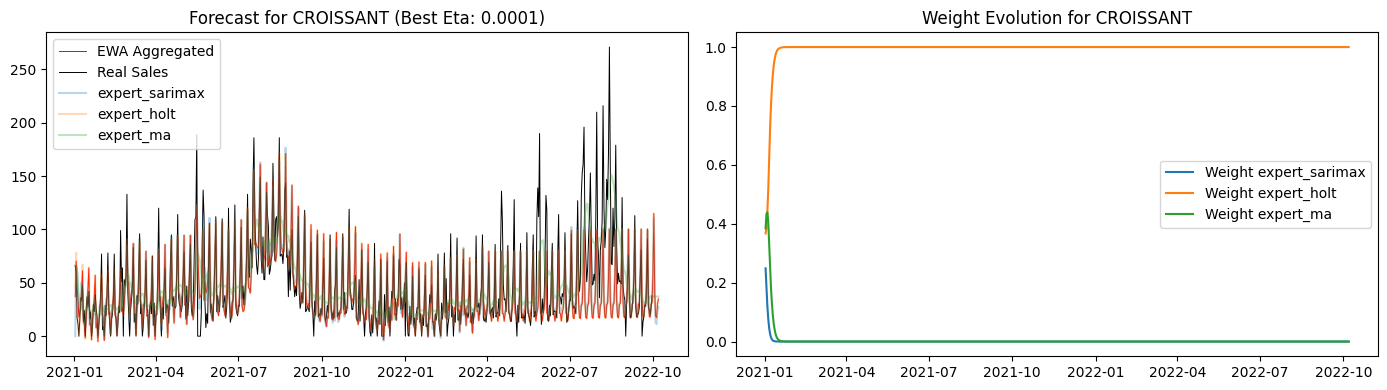

ECLAIR               | 0.0001     | 4.2449    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


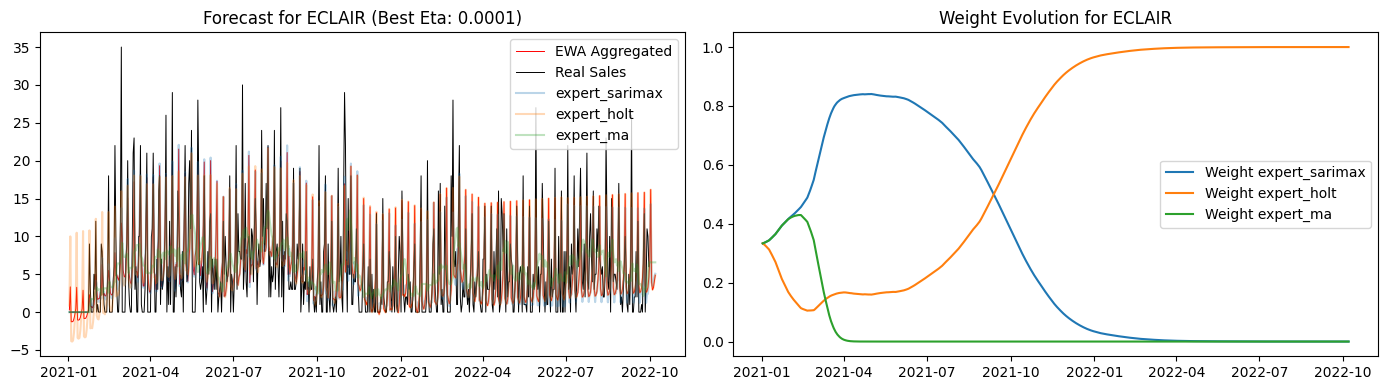

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


PAIN AU CHOCOLAT     | 0.0001     | 39.5540   


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


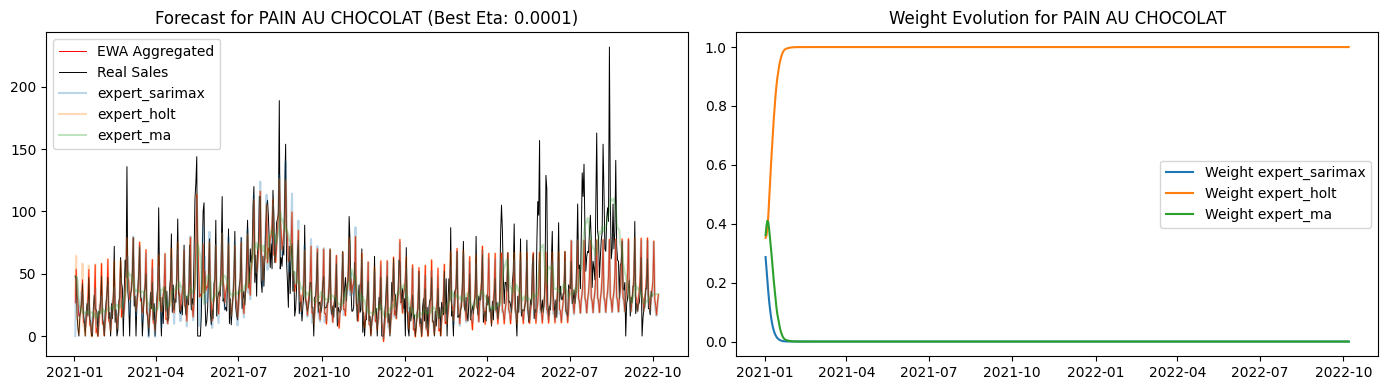

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


SPECIAL BREAD        | 0.01       | 4.4205    


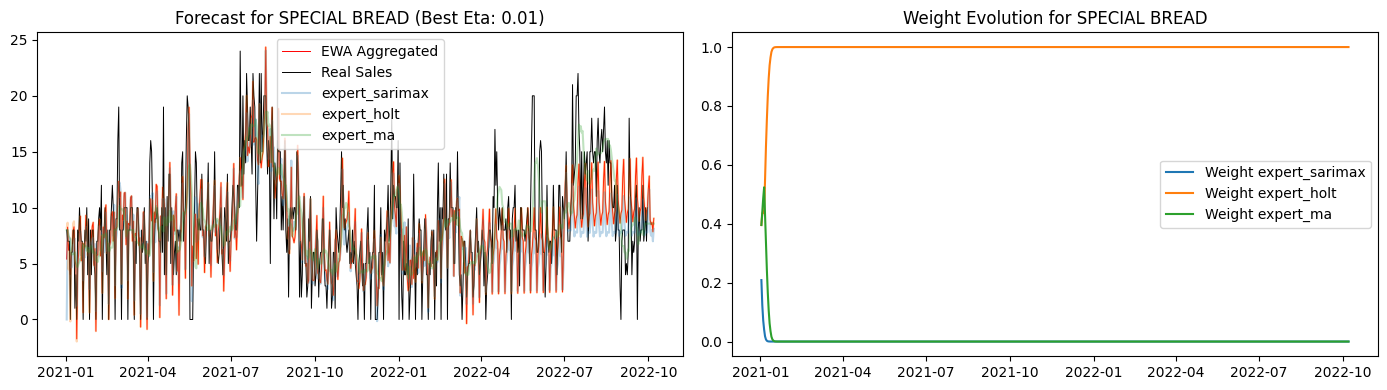

TARTELETTE           | 0.001      | 6.3162    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


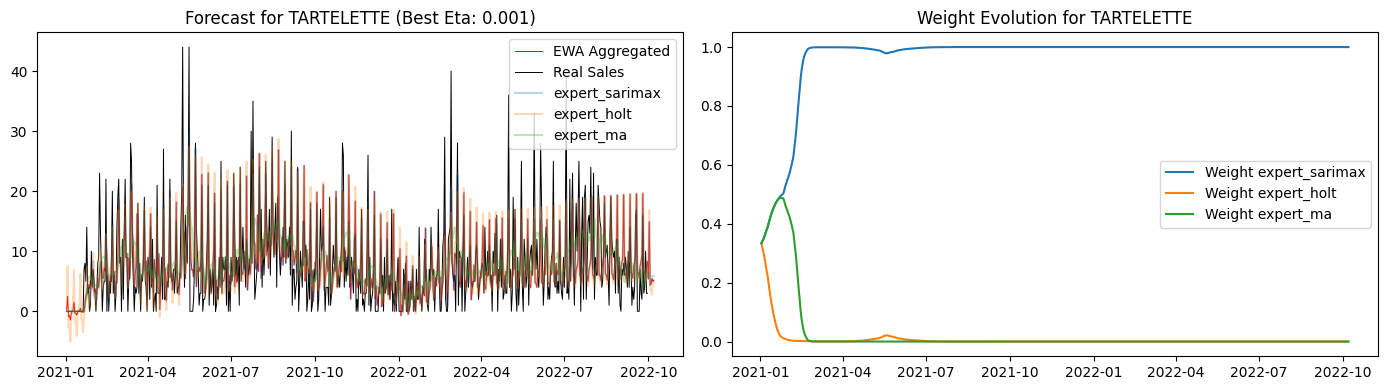

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3017315870.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


TRADITIONAL BAGUETTE | 0.0001     | 186.2615  


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/3611250833.py:15: RuntimeWarning: invalid value encountered in divide
  updated_weights /= np.sum(updated_weights)  # Normalize to sum to 1


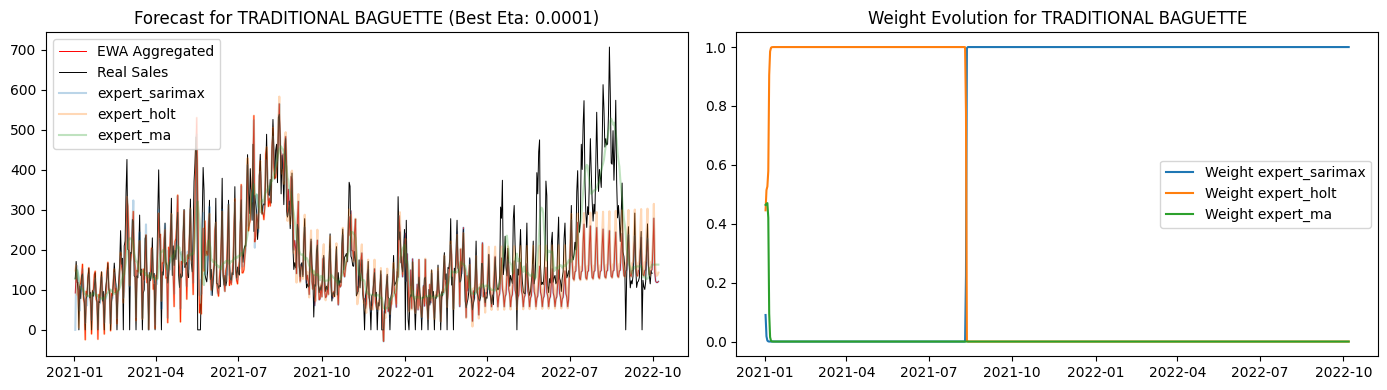


Files saved: 'predictions_with_ewa_3experts.csv'.


In [21]:
def run_ewa_analysis(input_csv):
    # Load and prepare data
    df = pd.read_csv(input_csv)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Parameters
    val_start = pd.to_datetime('2022-04-01')
    test_start = pd.to_datetime('2022-07-01')
    etas_to_test = [0.0001, 0.001, 0.01, 0.1, 0.5]
    expert_columns = ['expert_sarimax', 'expert_holt', 'expert_ma']
    
    products = df['product'].unique()
    all_updated_dfs = []
    
    print(f"{'Product':<20} | {'Best Eta':<10} | {'Test RMSE':<10}")
    print("-" * 45)

    for prod in products:
        # Extract product data
        prod_df = df[df['product'] == prod].sort_values('Date').copy()
        
        # NEW EXPERT: Moving Average J-7 
        # We shift by 1 to ensure we only use past data for the prediction
        prod_df['expert_ma'] = prod_df['real_sale'].shift(1).rolling(window=7, min_periods=1).mean()
        # Fill initial NaNs and propagate the last known MA to the future
        prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
        last_ma_val = prod_df.loc[prod_df['real_sale'].notna(), 'expert_ma'].iloc[-1]
        prod_df.loc[prod_df['real_sale'].isna(), 'expert_ma'] = last_ma_val
        
        # Split History (has real_sale) and Future (no real_sale)
        history_df = prod_df[prod_df['real_sale'].notna()].copy()
        future_df = prod_df[prod_df['real_sale'].isna()].copy()
        
        # eta TUNING
        best_eta = etas_to_test[0]
        min_rmse = float('inf')
        
        for eta in etas_to_test:
            preds, _ = ewa_forecasting(
                history_df[expert_columns].values, 
                history_df['real_sale'].values, 
                eta, 
                squared_loss
            )
            # Evaluate on validation period [val_start, test_start[
            val_mask = (history_df['Date'] >= val_start) & (history_df['Date'] < test_start)
            if val_mask.any():
                rmse = rmse_fn(history_df.loc[val_mask, 'real_sale'], preds[val_mask])
                if rmse < min_rmse:
                    min_rmse, best_eta = rmse, eta
        
        # run with best eta
        final_preds_hist, weights_hist = ewa_forecasting(
            history_df[expert_columns].values, 
            history_df['real_sale'].values, 
            best_eta, 
            squared_loss
        )
        
        # Calculate Test RMSE
        test_mask = (history_df['Date'] >= test_start)
        test_rmse = rmse_fn(history_df.loc[test_mask, 'real_sale'], final_preds_hist[test_mask])
        print(f"{prod:<20} | {best_eta:<10} | {test_rmse:<10.4f}")
        
        # Attach results to history
        history_df['ewa_prediction'] = final_preds_hist
        for i, col in enumerate(expert_columns):
            history_df[f'weight_{col}'] = weights_hist[:, i]
            
        # Handle Future predictions
        if not future_df.empty:
            last_weights = weights_hist[-1]
            future_df['ewa_prediction'] = np.dot(future_df[expert_columns].values, last_weights)
            for i, col in enumerate(expert_columns):
                future_df[f'weight_{col}'] = last_weights[i]
        
        prod_combined = pd.concat([history_df, future_df])
        all_updated_dfs.append(prod_combined)
        
        # Plot 1: Forecasts
        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
        axes[0].plot(prod_combined['Date'], prod_combined['ewa_prediction'], color='red', label='EWA Aggregated', linewidth=0.7)
        axes[0].plot(prod_combined['Date'], prod_combined['real_sale'], color='black', label='Real Sales', linewidth=0.7)
        for col in expert_columns:
            axes[0].plot(prod_combined['Date'], prod_combined[col], alpha=0.3, label=col)
        axes[0].set_title(f"Forecast for {prod} (Best Eta: {best_eta})")
        axes[0].legend()
        
        # Plot 2: Weights
        for col in expert_columns:
            axes[1].plot(prod_combined['Date'], prod_combined[f'weight_{col}'], label=f'Weight {col}')
        axes[1].set_title(f"Weight Evolution for {prod}")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].legend()

        # Save plots
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, f"{prod}_ewa_forecast_weights.png"))

        plt.show()


    # Save final CSV
    final_output = pd.concat(all_updated_dfs).sort_values(['product', 'Date'])
    final_output.to_csv("data_tmp/predictions_with_ewa_3experts.csv", index=False)
    print("\nFiles saved: 'predictions_with_ewa_3experts.csv'.")

run_ewa_analysis("data_tmp/predictions_experts_avec_futur.csv")

- Expert selection: The used experts are expert_sarimax, expert_holt (présents dans predictions_experts_avec_futur.csv) eand a moving average J-7.
- $\eta$ optimisation : for each product, the $\eta$ is chosen from [0.0001, 0.001, 0.01, 0.1, 0.5] by minimising the RMSE in the validation period (2022-04-01 to 2022-06-30).
- Weights prediction : weights were updated from past errors. For the "future periode (the one with no real sales), the last calculated weights were used.

| Product                 | Best η | RMSE (Test) |
|------------------------:|:----------:|------------:|
| BAGUETTE               |   0.0001   |     22.3176 |
| BANETTE                |   0.0001   |     29.6314 |
| BOULE 400G             |   0.0001   |      7.4191 |
| CAMPAGNE               |   0.001    |      6.2408 |
| CEREAL BAGUETTE        |   0.1      |      8.9396 |
| COOKIE                 |   0.5      |      7.3504 |
| CROISSANT              |   0.01     |     52.5475 |
| ECLAIR                 |   0.0001   |      4.2449 |
| PAIN AU CHOCOLAT       |   0.0001   |     39.5540 |
| SPECIAL BREAD          |   0.01     |      4.4205 |
| TARTELETTE             |   0.1      |      6.3828 |
| TRADITIONAL BAGUETTE   |   0.001    |    180.3488 |

Product              | Best Eta   | Test RMSE 
---------------------------------------------
BAGUETTE             | 0.5        | 18.2496   


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = w

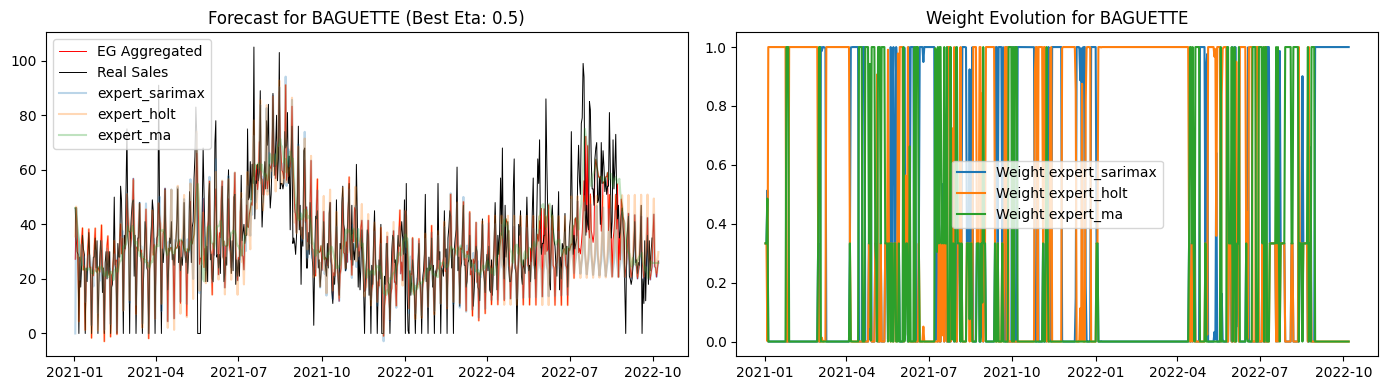

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = weights * np.exp(-eta * grad_t)


BANETTE              | 0.01       | 17.4857   


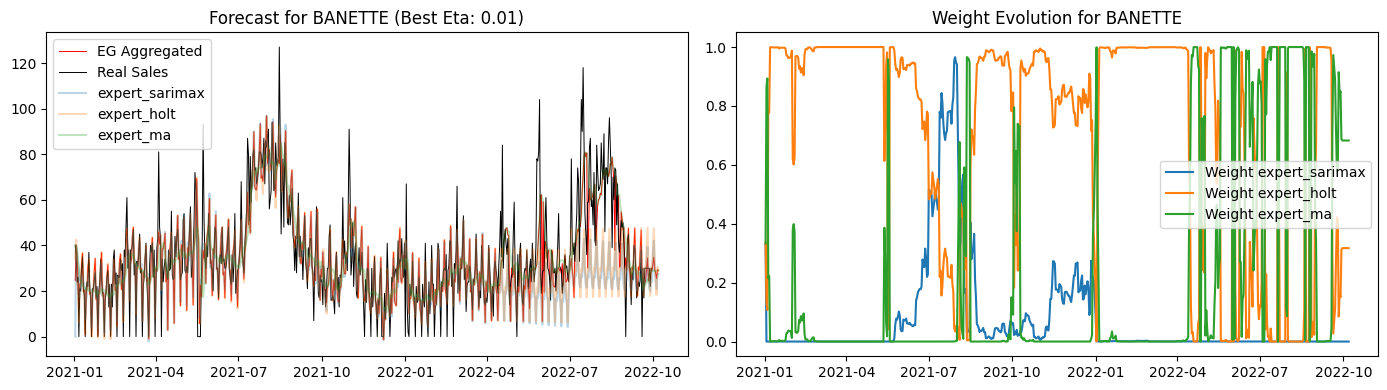

BOULE 400G           | 0.01       | 5.9168    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


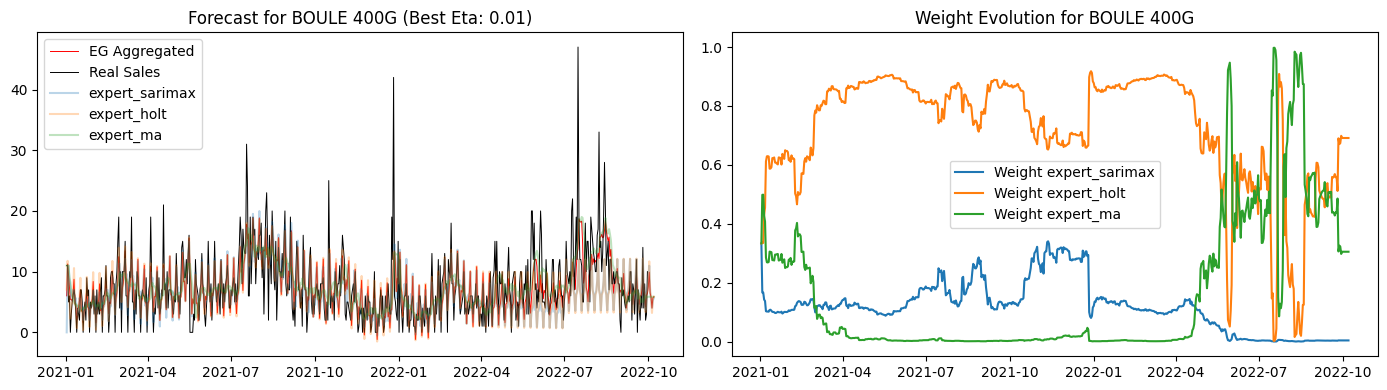

CAMPAGNE             | 0.01       | 3.5588    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


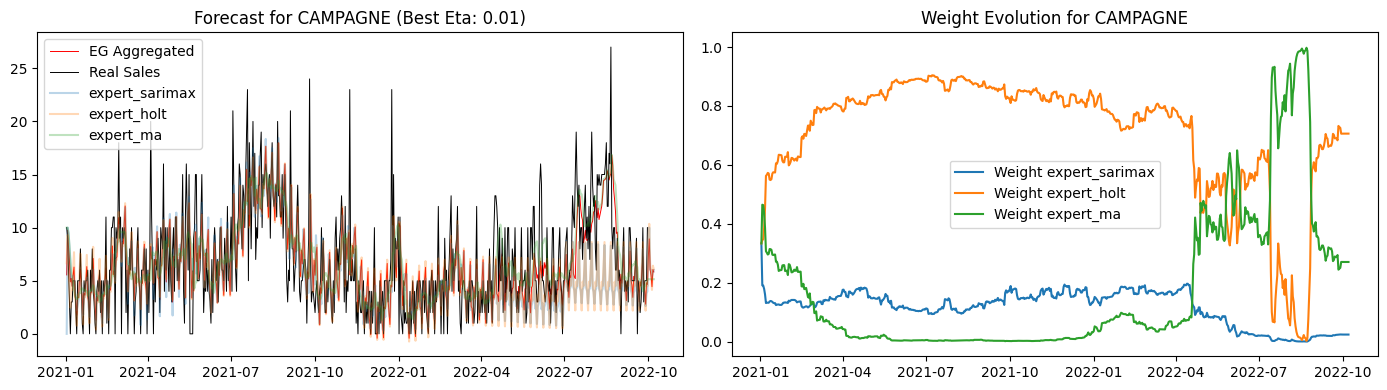

CEREAL BAGUETTE      | 0.01       | 4.2438    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


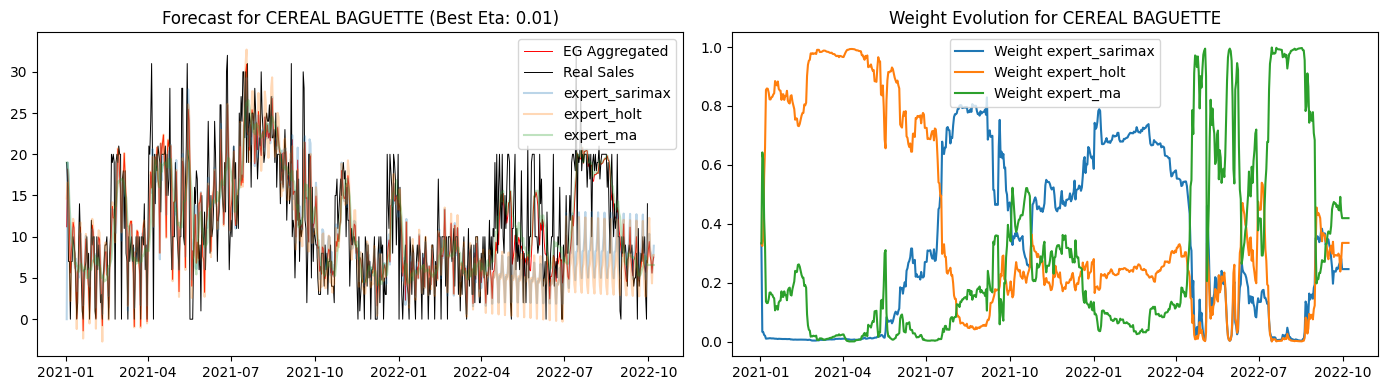

COOKIE               | 0.0001     | 5.9227    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


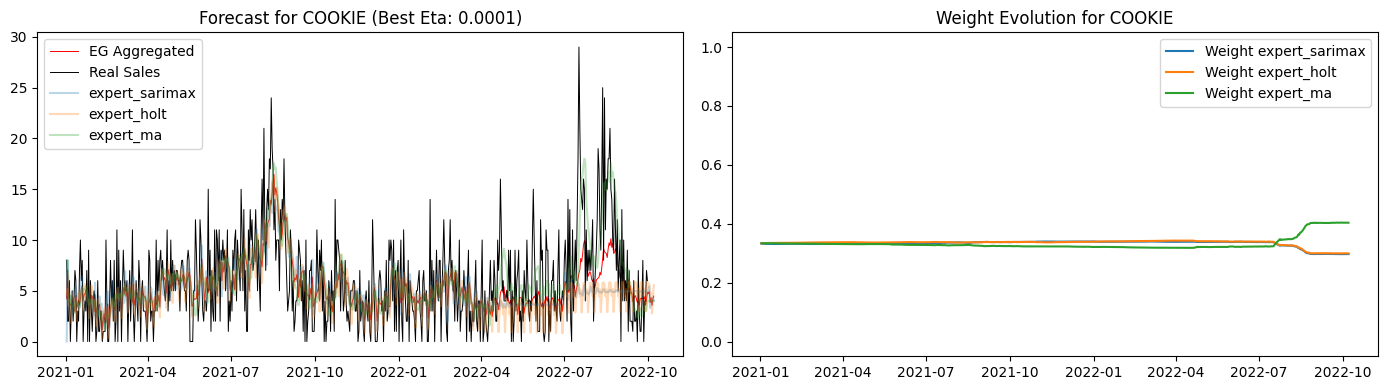

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = w

CROISSANT            | 0.001      | 40.9381   


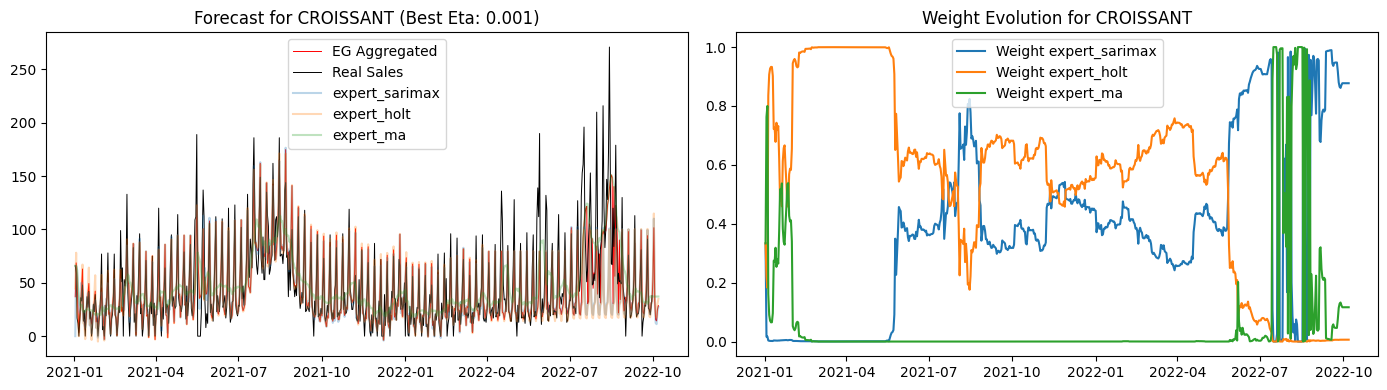

ECLAIR               | 0.0001     | 4.2673    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


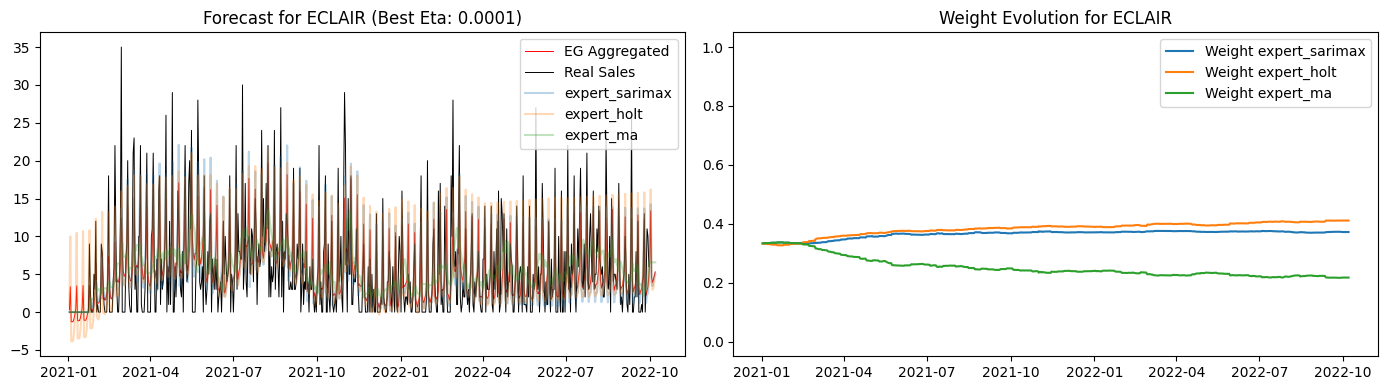

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = w

PAIN AU CHOCOLAT     | 0.0001     | 28.9634   


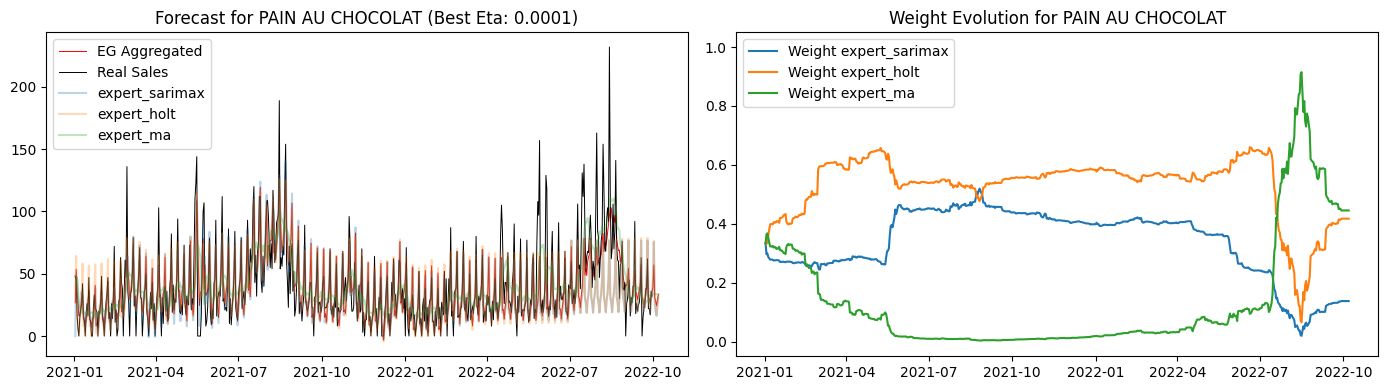

SPECIAL BREAD        | 0.01       | 3.4855    


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


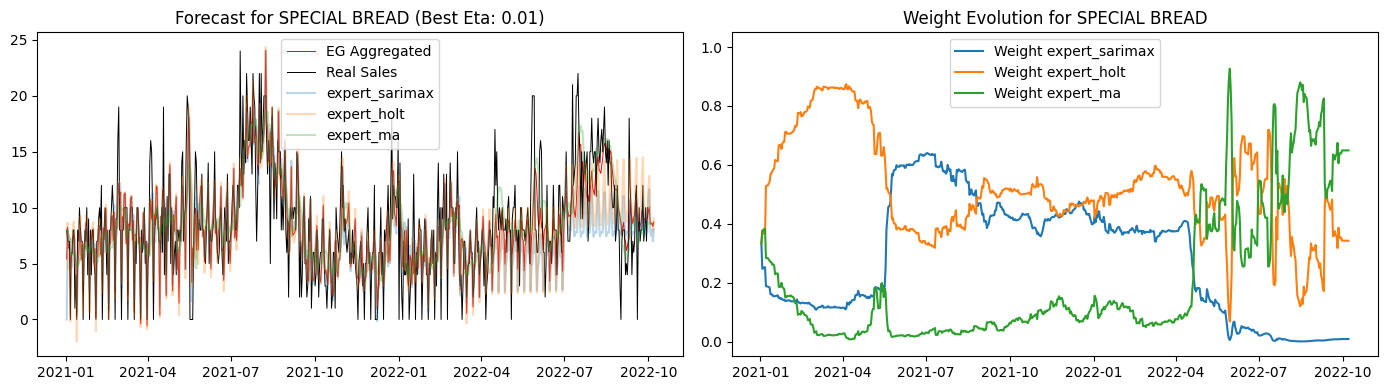

TARTELETTE           | 0.001      | 6.2183    

/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)


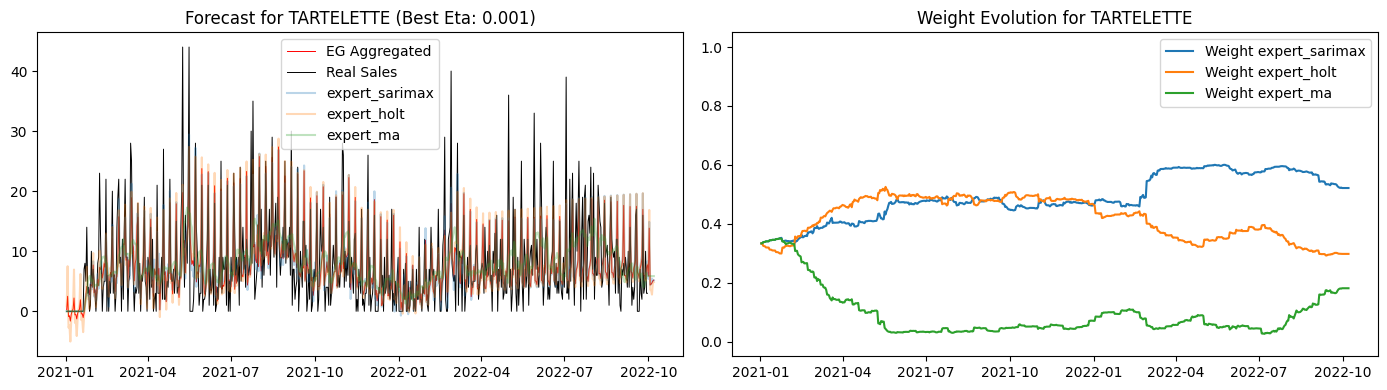

TRADITIONAL BAGUETTE | 0.0001     | 81.1456   


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2734985284.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: overflow encountered in exp
  updated_weights = weights * np.exp(-eta * grad_t)
/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_36896/2792211560.py:10: RuntimeWarning: invalid value encountered in multiply
  updated_weights = w

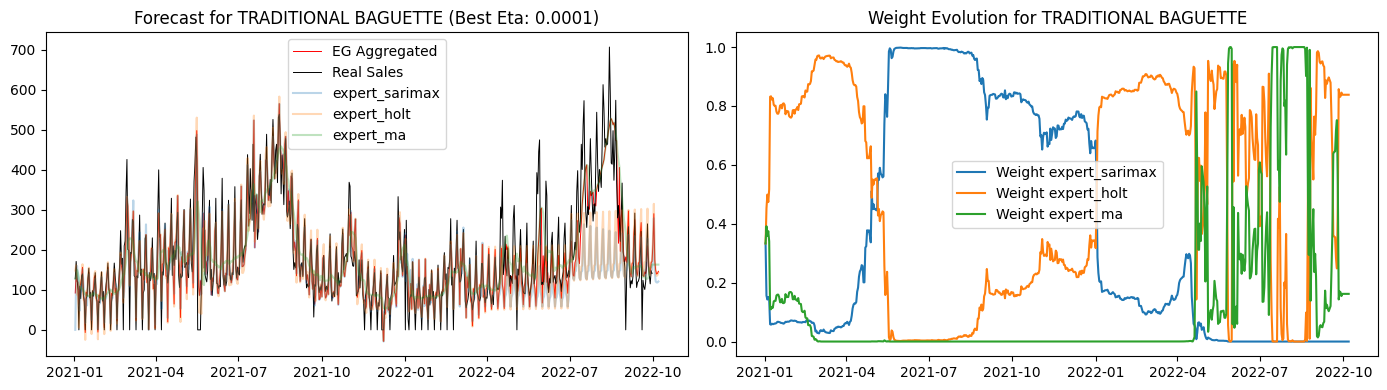


Files saved: 'predictions_with_eg_3experts.csv'.


In [22]:
def run_eg_analysis(input_csv):
    # Load and prepare data
    df = pd.read_csv(input_csv)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Parameters
    val_start = pd.to_datetime('2022-04-01')
    test_start = pd.to_datetime('2022-07-01')
    etas_to_test = [0.0001, 0.001, 0.01, 0.1, 0.5]
    expert_columns = ['expert_sarimax', 'expert_holt', 'expert_ma']
    
    products = df['product'].unique()
    all_updated_dfs = []
    
    print(f"{'Product':<20} | {'Best Eta':<10} | {'Test RMSE':<10}")
    print("-" * 45)

    for prod in products:
        # Extract product data
        prod_df = df[df['product'] == prod].sort_values('Date').copy()
        
        # NEW EXPERT: Moving Average J-7 
        # We shift by 1 to ensure we only use past data for the prediction
        prod_df['expert_ma'] = prod_df['real_sale'].shift(1).rolling(window=7, min_periods=1).mean()
        # Fill initial NaNs and propagate the last known MA to the future
        prod_df['expert_ma'] = prod_df['expert_ma'].fillna(method='bfill').fillna(0)
        last_ma_val = prod_df.loc[prod_df['real_sale'].notna(), 'expert_ma'].iloc[-1]
        prod_df.loc[prod_df['real_sale'].isna(), 'expert_ma'] = last_ma_val
        
        # Split History (has real_sale) and Future (no real_sale)
        history_df = prod_df[prod_df['real_sale'].notna()].copy()
        future_df = prod_df[prod_df['real_sale'].isna()].copy()
        
        # eta TUNING
        best_eta = etas_to_test[0]
        min_rmse = float('inf')
        
        for eta in etas_to_test:
            preds, _ = EG_forecasting(
                history_df[expert_columns].values, 
                history_df['real_sale'].values, 
                eta
            )
            # Evaluate on validation period [val_start, test_start[
            val_mask = (history_df['Date'] >= val_start) & (history_df['Date'] < test_start)
            if val_mask.any():
                rmse = rmse_fn(history_df.loc[val_mask, 'real_sale'], preds[val_mask])
                if rmse < min_rmse:
                    min_rmse, best_eta = rmse, eta
        
        # run with best eta (do not pass a 4th positional arg if EG_forecasting accepts 3)
        final_preds_hist, weights_hist = EG_forecasting(
            history_df[expert_columns].values, 
            history_df['real_sale'].values, 
            best_eta
        )
        
        # Calculate Test RMSE
        test_mask = (history_df['Date'] >= test_start)
        test_rmse = rmse_fn(history_df.loc[test_mask, 'real_sale'], final_preds_hist[test_mask])
        print(f"{prod:<20} | {best_eta:<10} | {test_rmse:<10.4f}")
        
        # Attach results to history
        history_df['eg_prediction'] = final_preds_hist
        for i, col in enumerate(expert_columns):
            history_df[f'weight_{col}_eg'] = weights_hist[:, i]
            
        # Handle Future predictions
        if not future_df.empty:
            last_weights = weights_hist[-1]
            future_df['eg_prediction'] = np.dot(future_df[expert_columns].values, last_weights)
            for i, col in enumerate(expert_columns):
                future_df[f'weight_{col}_eg'] = last_weights[i]
        
        prod_combined = pd.concat([history_df, future_df])
        all_updated_dfs.append(prod_combined)
        
        # Plot 1: Forecasts
        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
        axes[0].plot(prod_combined['Date'], prod_combined['eg_prediction'], color='red', label='EG Aggregated', linewidth=0.7)
        axes[0].plot(prod_combined['Date'], prod_combined['real_sale'], color='black', label='Real Sales', linewidth=0.7)
        for col in expert_columns:
            axes[0].plot(prod_combined['Date'], prod_combined[col], alpha=0.3, label=col)
        axes[0].set_title(f"Forecast for {prod} (Best Eta: {best_eta})")
        axes[0].legend()
        
        # Plot 2: Weights (use the _eg suffix as created above)
        for col in expert_columns:
            axes[1].plot(prod_combined['Date'], prod_combined[f'weight_{col}_eg'], label=f'Weight {col}')
        axes[1].set_title(f"Weight Evolution for {prod}")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].legend()

        # Save plots
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, f"{prod}_eg_forecast_weights.png"))

        plt.show()
    # Save final CSV
    final_output = pd.concat(all_updated_dfs).sort_values(['product', 'Date'])
    final_output.to_csv("data_tmp/predictions_with_eg_3experts.csv", index=False)
    print("\nFiles saved: 'predictions_with_eg_3experts.csv'.")

run_eg_analysis("data_tmp/predictions_experts_avec_futur.csv")

|Product              | Best Eta   | Test RMSE |
|---------------------:|:-----------:|----------:|
|BAGUETTE             | 0.5        | 18.2496   |
|BANETTE              | 0.01       | 17.4857   | 
|BOULE 400G           | 0.01       | 5.9168|
|CAMPAGNE             | 0.01       | 3.5588 |
|CEREAL BAGUETTE      | 0.01       | 4.2438  |  
|COOKIE               | 0.0001     | 5.9227|
|CROISSANT            | 0.001      | 40.9381|  
|ECLAIR               | 0.0001     | 4.2673 |
|PAIN AU CHOCOLAT     | 0.0001     | 28.9634|
|SPECIAL BREAD        | 0.01       | 3.4855 |
|TARTELETTE           | 0.001      | 6.2183  |
|TRADITIONAL BAGUETTE | 0.0001     | 81.1456 |